In [1]:
import cv2
import mediapipe as mp
import numpy as np
from tqdm import tqdm

print("OpenCV:", cv2.__version__)
print("MediaPipe:", mp.__version__)
print("NumPy:", np.__version__)
print("All imports successful ✅")

OpenCV: 5.0.0
MediaPipe: 1.0.1
NumPy: 2.5.3
All imports successful ✅


In [1]:
import mediapipe as mp

print("Version:", mp.__version__)
print("Has solutions?", hasattr(mp, "solutions"))
print("Imported from:", mp.__file__)

Version: 0.10.21
Has solutions? True
Imported from: c:\Users\palak\AppData\Local\Programs\Python\Python312\Lib\site-packages\mediapipe\__init__.py


In [2]:
import cv2
import mediapipe as mp
import numpy as np

mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

print("✅ MediaPipe initialized successfully!")

✅ MediaPipe initialized successfully!


In [3]:
import os

INCLUDE_PATH = os.path.join("..", "dataset", "raw", "include")

sample_video = None

for part in sorted(os.listdir(INCLUDE_PATH)):
    part_path = os.path.join(INCLUDE_PATH, part)

    if os.path.isdir(part_path):
        for category in sorted(os.listdir(part_path)):
            category_path = os.path.join(part_path, category)

            if os.path.isdir(category_path):
                for sign in sorted(os.listdir(category_path)):
                    sign_path = os.path.join(category_path, sign)

                    if os.path.isdir(sign_path):
                        videos = [
                            v for v in os.listdir(sign_path)
                            if v.endswith((".MOV", ".MP4", ".avi", ".mov"))
                        ]

                        if videos:
                            sample_video = os.path.join(sign_path, videos[0])

                            print("✅ Sample video found!")
                            print("Category :", category)
                            print("Sign     :", sign)
                            print("Video     :", videos[0])
                            break

                if sample_video:
                    break
        if sample_video:
            break

✅ Sample video found!
Category : Adjectives
Sign     : 1. loud
Video     : MVI_5177.MOV


In [4]:
import cv2

cap = cv2.VideoCapture(sample_video)

frame_count = 0

while cap.isOpened():
    success, frame = cap.read()

    if not success:
        break

    frame_count += 1

    # Resize so it fits nicely
    frame = cv2.resize(frame, (640, 480))

    cv2.imshow("INCLUDE Sample Video", frame)

    # Press Q to stop early
    if cv2.waitKey(25) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

print("✅ Total Frames Read:", frame_count)

✅ Total Frames Read: 56


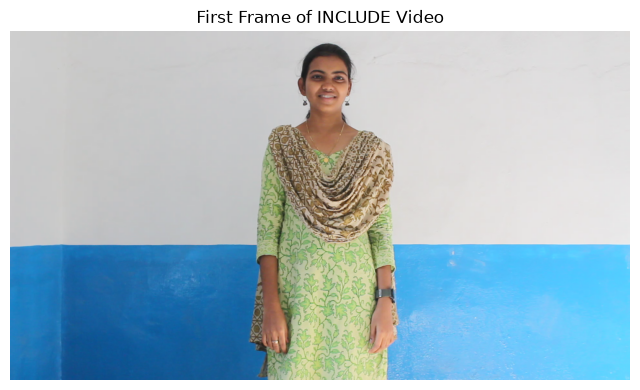

✅ First frame displayed successfully.


In [5]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(sample_video)

success, frame = cap.read()
cap.release()

if success:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,6))
    plt.imshow(frame)
    plt.title("First Frame of INCLUDE Video")
    plt.axis("off")
    plt.show()

    print("✅ First frame displayed successfully.")
else:
    print("❌ Could not read frame.")

✅ Hand landmarks detected!


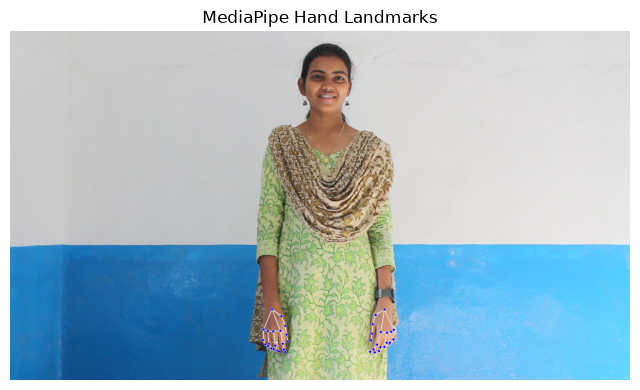

In [6]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.5
)

# Read first frame again
cap = cv2.VideoCapture(sample_video)
success, frame = cap.read()
cap.release()

if success:
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Detect hands
    results = hands.process(rgb_frame)

    # Draw landmarks if hands are found
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_draw.draw_landmarks(
                rgb_frame,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS
            )

        print("✅ Hand landmarks detected!")
    else:
        print("❌ No hands detected.")

    # Show image with landmarks
    plt.figure(figsize=(8,6))
    plt.imshow(rgb_frame)
    plt.axis("off")
    plt.title("MediaPipe Hand Landmarks")
    plt.show()

In [7]:
import numpy as np

if results.multi_hand_landmarks:

    # Take the first detected hand
    hand = results.multi_hand_landmarks[0]

    landmarks = []

    for point in hand.landmark:
        landmarks.extend([point.x, point.y, point.z])

    landmarks = np.array(landmarks)

    print("✅ Landmark vector shape:", landmarks.shape)
    print("\nFirst 15 values:\n")
    print(landmarks[:15])

else:
    print("No landmarks found.")

✅ Landmark vector shape: (63,)

First 15 values:

[ 6.04147255e-01  7.98030376e-01  1.17355263e-07  5.89864910e-01
  8.12999964e-01 -4.15748078e-03  5.85282743e-01  8.40625286e-01
 -6.14834763e-03  5.83922029e-01  8.67415905e-01 -6.72366237e-03
  5.82735837e-01  8.86721194e-01 -6.69335900e-03]


In [8]:
import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

cap = cv2.VideoCapture(sample_video)

sequence = []

while cap.isOpened():
    success, frame = cap.read()

    if not success:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb)

    frame_landmarks = np.zeros(63)

    if results.multi_hand_landmarks:
        hand = results.multi_hand_landmarks[0]

        coords = []
        for point in hand.landmark:
            coords.extend([point.x, point.y, point.z])

        frame_landmarks = np.array(coords)

    sequence.append(frame_landmarks)

cap.release()

sequence = np.array(sequence)

print("Sequence shape:", sequence.shape)
print("Frames processed:", len(sequence))

Sequence shape: (56, 63)
Frames processed: 56


In [9]:
import os
import numpy as np

# Create processed folder if it doesn't exist
PROCESSED_PATH = os.path.join("..", "dataset", "processed")
os.makedirs(PROCESSED_PATH, exist_ok=True)

# Save the landmark sequence
save_path = os.path.join(PROCESSED_PATH, "sample_landmarks.npy")
np.save(save_path, sequence)

print("✅ Landmark sequence saved!")
print("Saved at:", os.path.abspath(save_path))

✅ Landmark sequence saved!
Saved at: c:\Users\palak\SANKETSETU\dataset\processed\sample_landmarks.npy
